In [8]:
import numpy as np
import matplotlib.pyplot as plt


In [10]:
np.random.seed(42)
n = 600             # Total time points
features = 3        # Number of signals/variables

# Create 3 segments with different means
seg1 = np.random.normal(0, 1, (n // 3, features))
seg2 = np.random.normal(3, 1, (n // 3, features))
seg3 = np.random.normal(-2, 1, (n // 3, features))

# Combine all segments into one time series
data = np.vstack((seg1, seg2, seg3))  # Shape: (600, 3)

In [12]:
def multivariate_segment_cost(segment):
    cov = np.cov(segment, rowvar=False)  # Compute covariance matrix
    det = np.linalg.det(cov + np.eye(cov.shape[0]) * 1e-6)  # Avoid singular matrices
    length = len(segment)
    return length * np.log(det + 1e-6)

In [14]:
def multivariate_mdl_segmentation(data, window_size=50, step=10, threshold=10):
    change_points = []
    i = 0
    while i + 2 * window_size <= len(data):
        left = data[i:i + window_size]
        right = data[i + window_size:i + 2 * window_size]
        full = np.vstack((left, right))

        cost_full = multivariate_segment_cost(full)
        cost_split = multivariate_segment_cost(left) + multivariate_segment_cost(right)

        if cost_split + threshold < cost_full:
            change_point = i + window_size
            change_points.append(change_point)
            i += window_size  # Skip ahead to avoid overlapping detections
        else:
            i += step  # Slide forward if no change
    return change_points

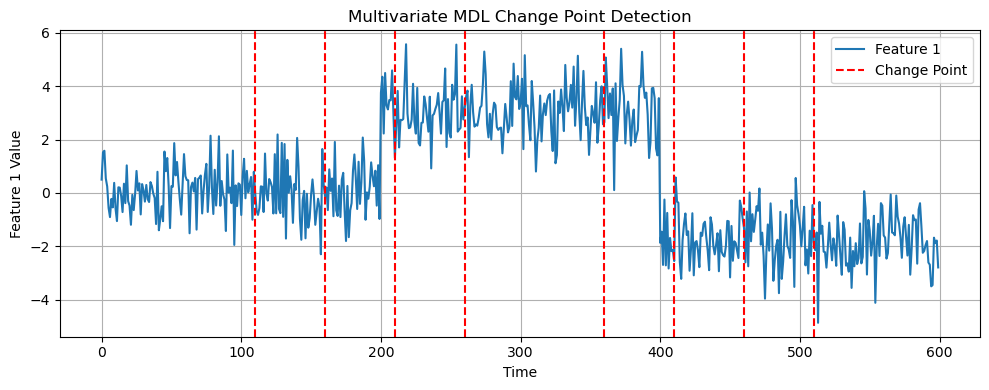

Detected Change Points: [110, 160, 210, 260, 360, 410, 460, 510]


In [16]:
change_points = multivariate_mdl_segmentation(data)

plt.figure(figsize=(10, 4))
plt.plot(data[:, 0], label='Feature 1')  # Just showing one feature for clarity
for cp in change_points:
    plt.axvline(cp, color='red', linestyle='--', label='Change Point' if cp == change_points[0] else "")
plt.title("Multivariate MDL Change Point Detection")
plt.xlabel("Time")
plt.ylabel("Feature 1 Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("Detected Change Points:", change_points)